In [30]:
import pandas as pd
import mlflow

In [31]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Fraud Detection")

<Experiment: artifact_location='file:C:/Users/trixr/Desktop/FraudDetection/mlflow-data/artifacts/1', creation_time=1781179797941, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781179797941, lifecycle_stage='active', name='Fraud Detection', tags={}, trace_location=None, workspace='default'>

In [32]:
mlflow.start_run(run_name="FeatureEngineering")

<ActiveRun: >

In [33]:
from pathlib import Path

DATA_PATH = Path("./Data")
RAW_DATA_PATH = DATA_PATH / "raw" / "Fraud_Data.csv"
PROCESSED_DATA_PATH = DATA_PATH / "processed"

PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Load Data with correct Types

In [34]:
df = pd.read_csv(
    RAW_DATA_PATH,
    parse_dates=["signup_time", "purchase_time"]
)

In [35]:
import ipaddress

df["ip_address"] = df["ip_address"].astype("int64").apply(
    lambda x: str(ipaddress.IPv4Address(x))
)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  object        
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 12.7+ MB


# Time Velocity

In [37]:
df["time_velocity"] = (
    df["purchase_time"] - df["signup_time"]
).dt.total_seconds()

# Sharing

In [38]:
df = df.sort_values("signup_time")

ip_seen_users = {}
device_seen_users = {}

ip_counts = []
device_counts = []

for _, row in df.iterrows():
    ip = row["ip_address"]
    device = row["device_id"]
    user = row["user_id"]

    # IP feature
    if ip not in ip_seen_users:
        ip_seen_users[ip] = set()
    ip_counts.append(len(ip_seen_users[ip]))

    # Device feature
    if device not in device_seen_users:
        device_seen_users[device] = set()
    device_counts.append(len(device_seen_users[device]))

    # update AFTER computing feature (important to avoid leakage)
    ip_seen_users[ip].add(user)
    device_seen_users[device].add(user)

df["ip_user_share_count"] = ip_counts
df["device_user_share_count"] = device_counts

# Purchase Day, Hour

In [39]:
df["day"] = df["purchase_time"].dt.day
df["hour"] = df["purchase_time"].dt.hour

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151112 entries, 131113 to 38972
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   user_id                  151112 non-null  int64         
 1   signup_time              151112 non-null  datetime64[ns]
 2   purchase_time            151112 non-null  datetime64[ns]
 3   purchase_value           151112 non-null  int64         
 4   device_id                151112 non-null  object        
 5   source                   151112 non-null  object        
 6   browser                  151112 non-null  object        
 7   sex                      151112 non-null  object        
 8   age                      151112 non-null  int64         
 9   ip_address               151112 non-null  object        
 10  class                    151112 non-null  int64         
 11  time_velocity            151112 non-null  float64       
 12  ip_user_share_cou

# Binning

In [41]:
age_splits = [-np.inf, 25.0, 35.0, 45.0, 55.0, np.inf]
purchase_splits = [-np.inf, 20.0, 40.0, 60.0, 80.0, np.inf]

df["age_manual_binned"] = pd.cut(
    df["age"], bins=age_splits, labels=False
)

df["purchase_value_manual_binned"] = pd.cut(
    df["purchase_value"], bins=purchase_splits, labels=False
)

C:\Users\trixr\AppData\Local\Temp\ipykernel_22804\366206649.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["<=25", "25-35", "35-45", "45-55", "55+"])
C:\Users\trixr\AppData\Local\Temp\ipykernel_22804\366206649.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["<=20", "20-40", "40-60", "60-80", "80+"])


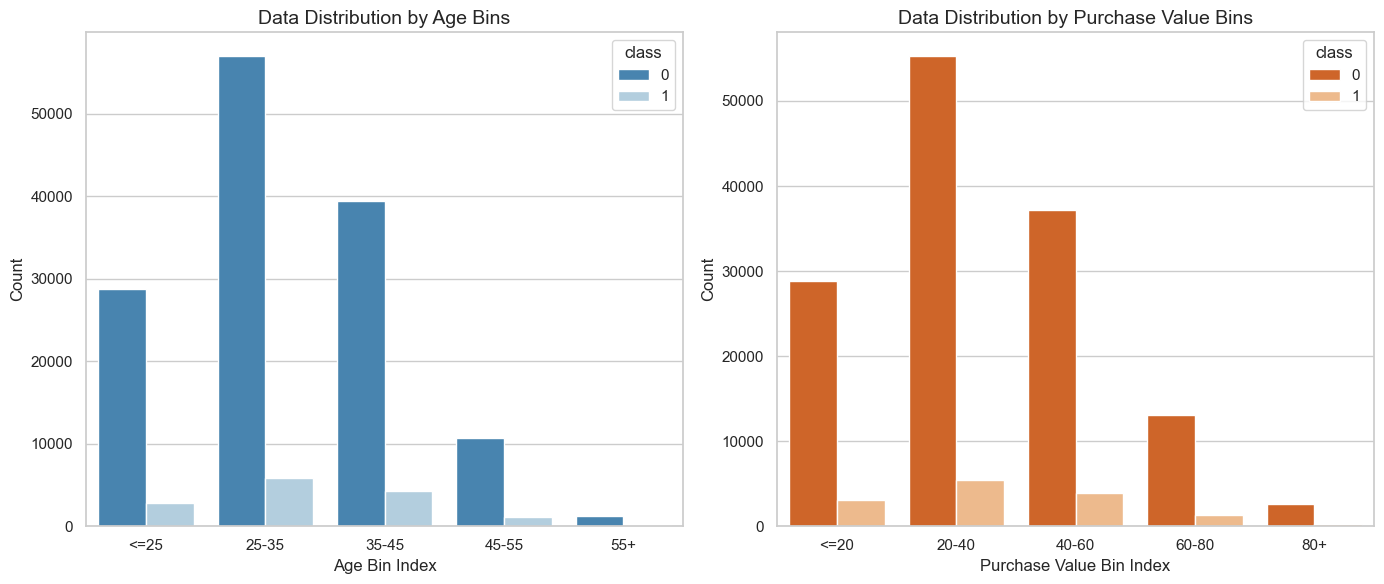

<Figure size 640x480 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(
    data=df,
    x="age_manual_binned",
    hue="class",
    ax=axes[0],
    palette="Blues_r",
)
axes[0].set_title("Data Distribution by Age Bins", fontsize=14)
axes[0].set_xlabel("Age Bin Index", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xticklabels(["<=25", "25-35", "35-45", "45-55", "55+"])

sns.countplot(
    data=df,
    x="purchase_value_manual_binned",
    hue="class",
    ax=axes[1],
    palette="Oranges_r",
)
axes[1].set_title("Data Distribution by Purchase Value Bins", fontsize=14)
axes[1].set_xlabel("Purchase Value Bin Index", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_xticklabels(["<=20", "20-40", "40-60", "60-80", "80+"])

plt.tight_layout()
plt.show()

fig = plt.gcf()
mlflow.log_figure(fig, "FE/DataDistribution_binning.png")


# Save CSV

In [43]:
df.to_csv(
    PROCESSED_DATA_PATH / "1_feature_engineering_result.csv",
    index=False,
        )

In [44]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,time_velocity,ip_user_share_count,device_user_share_count,day,hour,age_manual_binned,purchase_value_manual_binned
131113,286057,2015-01-01 00:00:42,2015-03-25 11:33:06,14,BBPACGBUVJUXF,Ads,Chrome,F,38,119.75.87.223,0,7212744.0,0,0,25,11,2,0
115086,309557,2015-01-01 00:00:43,2015-01-01 00:00:44,14,BBPACGBUVJUXF,Ads,Chrome,F,38,119.75.87.223,1,1.0,1,1,1,0,2,0
41990,124539,2015-01-01 00:00:44,2015-01-01 00:00:45,14,BBPACGBUVJUXF,Ads,Chrome,F,38,119.75.87.223,1,1.0,2,2,1,0,2,0
134836,161246,2015-01-01 00:00:45,2015-01-01 00:00:46,14,BBPACGBUVJUXF,Ads,Chrome,F,38,119.75.87.223,1,1.0,3,3,1,0,2,0
24572,356414,2015-01-01 00:00:46,2015-01-01 00:00:47,14,BBPACGBUVJUXF,Ads,Chrome,F,38,119.75.87.223,1,1.0,4,4,1,0,2,0


In [45]:
mlflow.log_artifact(PROCESSED_DATA_PATH / "1_feature_engineering_result.csv", artifact_path="data")

In [46]:
from collections import defaultdict

# Build a string report
report_lines = []
report_lines.append("DataFrame Summary")
report_lines.append("=" * 50)
report_lines.append(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
report_lines.append("\nSummary of Feature Engineering Stage:")
report_lines.append(
"""
 ip_address: Convert to proper IP Address format
 time_velocity: diff of Sign in and purchase time
 ip_user_share_count, device_user_share_count: We used expanding window method to pervent data leakage    
 day, hour: Extract purchase day of the month and time 
 binning: to extract more robustly reducing noise and see non-linear relationships easily
"""
)
report_str = "\n".join(report_lines)

# Log to MLflow (within an active run)
mlflow.log_text(report_str, "fe/dataframe_summary.txt")

In [47]:
mlflow.end_run()

🏃 View run FeatureEngineering at: http://localhost:5000/#/experiments/1/runs/0977481ed7624137b692d631e8d2aded
🧪 View experiment at: http://localhost:5000/#/experiments/1
